# Detecting Profession Mentions in COVID-19 Tweets (NLP)

## Context

During the COVID-19 pandemic, certain professions were disproportionately affected: healthcare workers, essential service providers, delivery personnel. Identifying which professions are being discussed on social media can help public health authorities understand vulnerability patterns and target protective measures.

This project builds a **binary classifier** that, given a tweet in Spanish, determines whether it mentions a profession (label `1`) or not (label `0`). It uses data from the [ProfNER shared task](https://temu.bsc.es/smm4h-spanish), a community evaluation challenge focused on profession detection in tweets during the pandemic.

## Approach

The classifier is built by **fine-tuning a pre-trained Transformer model** ([TwHIN-BERT](https://huggingface.co/Twitter/twhin-bert-base)) on the ProfNER training data. TwHIN-BERT was selected because it was pre-trained on multilingual Twitter data, making it particularly well-suited for short, informal Spanish text with hashtags, mentions, and abbreviations, domains where general-purpose language models tend to underperform.

## Dataset

The dataset is hosted on [Hugging Face](https://huggingface.co/datasets/luisgasco/profner_classification_master) and contains three splits: training, validation, and test. Each example consists of a tweet ID, the tweet text, and a binary label.

## 1. Setup

In [1]:
# Install dependencies
!pip install -q datasets transformers evaluate
!pip install -q fsspec==2023.9.2
!pip install -q --upgrade datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from wordcloud import WordCloud

from datasets import load_dataset, Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments)
from sklearn.metrics import accuracy_score, f1_score, classification_report

import os
os.environ['WANDB_DISABLED'] = 'true'

import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading

In [3]:
dataset = load_dataset('luisgasco/profner_classification_master')

train_df = dataset['train'].to_pandas()
val_df   = dataset['validation'].to_pandas()
test_df  = dataset['test'].to_pandas()

print(f'Training:   {len(train_df):,} tweets')
print(f'Validation: {len(val_df):,} tweets')
print(f'Test:       {len(test_df):,} tweets')

Training:   2,786 tweets
Validation: 999 tweets
Test:       1,001 tweets


## 3. Exploratory Data Analysis

### 3.1. Class distribution

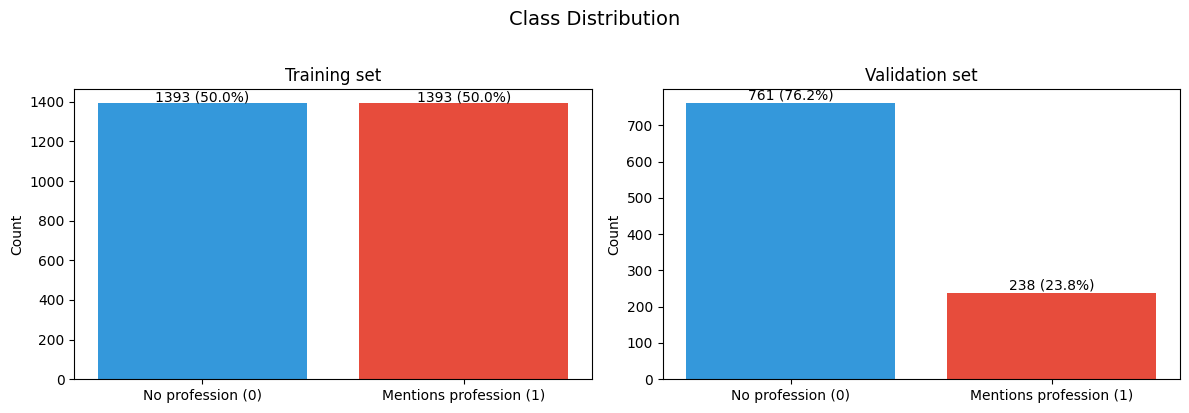

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(axes, [train_df, val_df], ['Training', 'Validation']):
    counts = df['label'].value_counts().sort_index()
    labels = ['No profession (0)', 'Mentions profession (1)']
    colors = ['#3498db', '#e74c3c']
    ax.bar(labels, counts.values, color=colors)
    ax.set_title(f'{title} set', fontsize=12)
    ax.set_ylabel('Count')
    for i, (v, c) in enumerate(zip(counts.values, counts.values)):
        pct = f'{v/len(df)*100:.1f}%'
        ax.text(i, v + 10, f'{v} ({pct})', ha='center', fontsize=10)

plt.suptitle('Class Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.2. Duplicates check

In [5]:
print(f'Duplicates in training:   {train_df.duplicated().sum()}')
print(f'Duplicates in validation: {val_df.duplicated().sum()}')

Duplicates in training:   0
Duplicates in validation: 0


### 3.3. Tweet length distribution

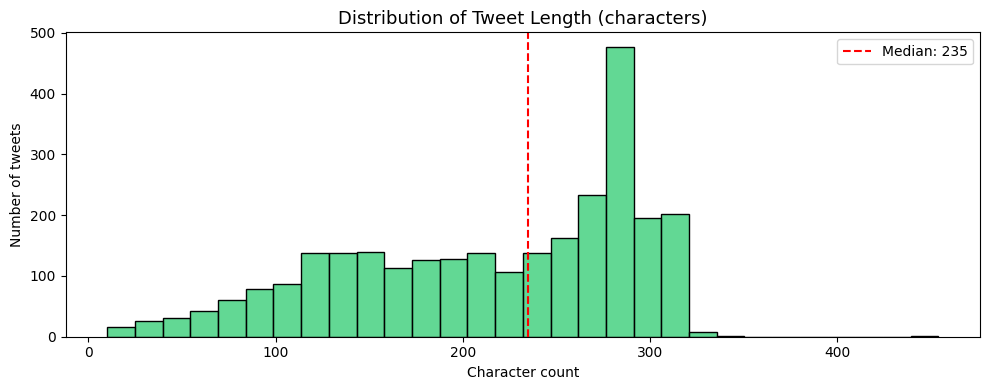

In [6]:
train_df['tweet_length'] = train_df['text'].apply(len)

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(train_df['tweet_length'], bins=30, color='#2ecc71', ax=ax)
ax.set_title('Distribution of Tweet Length (characters)', fontsize=13)
ax.set_xlabel('Character count')
ax.set_ylabel('Number of tweets')
ax.axvline(train_df['tweet_length'].median(), color='red', linestyle='--',
           label=f'Median: {train_df["tweet_length"].median():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

Most tweets fall between 200 and 300 characters. The distribution is right-skewed, climbing steadily until around 300 characters, then dropping sharply, likely reflecting Twitter's character limit.

### 3.4. Word clouds by class

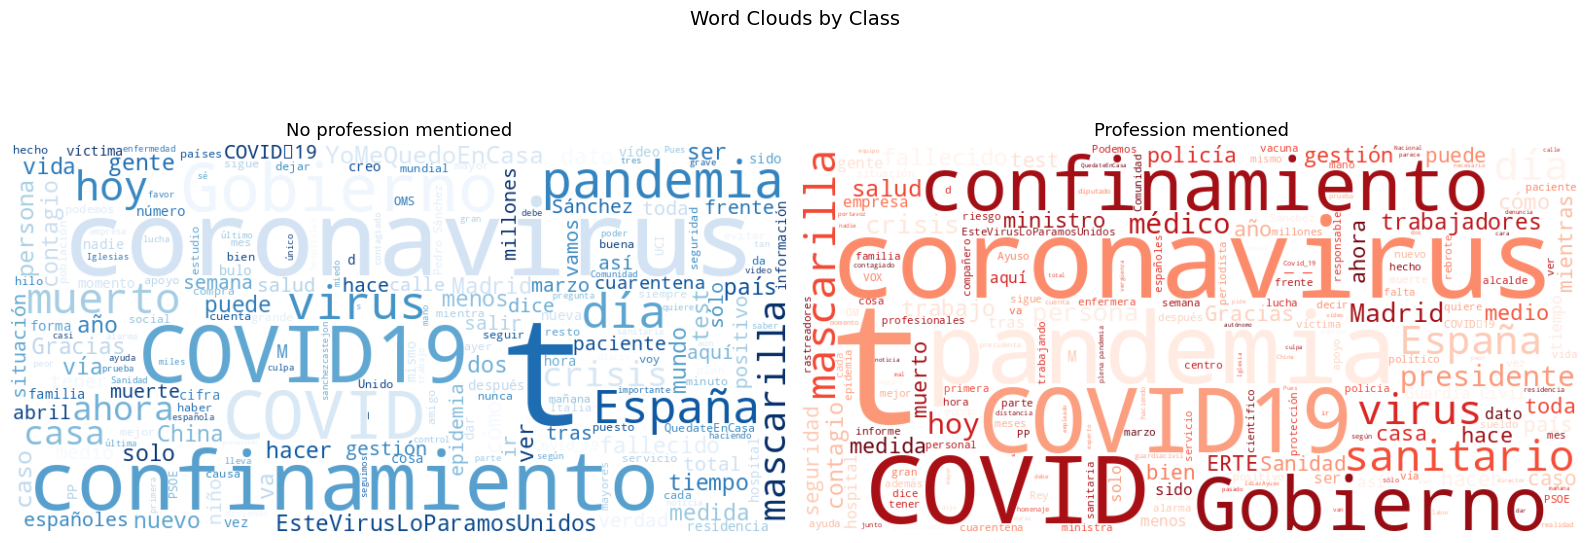

In [7]:
stopwords_es = set(stopwords.words('spanish'))
stopwords_es.update(['https', 'rt', 'q', 'si', 'co', 'amp'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, title, cmap in zip(
    axes, [0, 1],
    ['No profession mentioned', 'Profession mentioned'],
    ['Blues', 'Reds']
):
    text = ' '.join(train_df[train_df['label'] == label]['text'].astype(str))
    wc = WordCloud(
        stopwords=stopwords_es, width=800, height=400,
        background_color='white', colormap=cmap
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13)
    ax.axis('off')

plt.suptitle('Word Clouds by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The word clouds reveal no clear difference.

## 4. Model Selection

### Why TwHIN-BERT?

For this task, I selected [**TwHIN-BERT**](https://huggingface.co/Twitter/twhin-bert-base) (`Twitter/twhin-bert-base`), a BERT model pre-trained by Twitter on a large corpus of multilingual tweets.

The selection was based on three criteria:

1. **Domain match**: The data consists of tweets: short, informal text with hashtags, mentions, URLs, and abbreviations. A model pre-trained on tweets already understands this register, reducing the gap between pre-training and fine-tuning domains.

2. **Language coverage**: TwHIN-BERT is multilingual and includes Spanish in its pre-training data, which is essential since the ProfNER tweets are entirely in Spanish.

3. **Task suitability**: As a BERT-base architecture, it supports sequence classification out of the box via a classification head, and is efficient enough to fine-tune on a dataset of this size (~6K examples) without requiring excessive compute.

In [8]:
model_name = 'Twitter/twhin-bert-base'

## 5. Tokenization

In [9]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_batch(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=128)

# Convert to Hugging Face datasets and tokenize
train_dataset = Dataset.from_pandas(train_df).map(tokenize_batch, batched=True)
val_dataset = Dataset.from_pandas(val_df).map(tokenize_batch, batched=True)
test_dataset = Dataset.from_pandas(test_df).map(tokenize_batch, batched=True)

# Rename label column and set format
for ds in [train_dataset, val_dataset, test_dataset]:
    ds = ds.rename_column('label', 'labels')

train_dataset = train_dataset.rename_column('label', 'labels')
val_dataset = val_dataset.rename_column('label', 'labels')
test_dataset = test_dataset.rename_column('label', 'labels')

cols = ['input_ids', 'attention_mask', 'labels']
train_dataset.set_format(type='torch', columns=cols)
val_dataset.set_format(type='torch', columns=cols)
test_dataset.set_format(type='torch', columns=cols)

print(f'Tokenization complete. Max length: 128 tokens.')
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

Map:   0%|          | 0/2786 [00:00<?, ? examples/s]

Map:   0%|          | 0/999 [00:00<?, ? examples/s]

Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

Tokenization complete. Max length: 128 tokens.
Train: 2786, Val: 999, Test: 1001


## 6. Fine-tuning

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: Twitter/twhin-bert-base
Key                                                                  | Status     | 
---------------------------------------------------------------------+------------+-
bert.encoder.layer.{0...11}.attention.self.distance_embedding.weight | UNEXPECTED | 
cls.predictions.bias                                                 | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight                           | UNEXPECTED | 
cls.predictions.transform.dense.bias                                 | UNEXPECTED | 
cls.predictions.transform.dense.weight                               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias                             | UNEXPECTED | 
bert.pooler.dense.weight                                             | MISSING    | 
classifier.bias                                                      | MISSING    | 
classifier.weight                                              

In [11]:
training_args = TrainingArguments(
    output_dir='./results',
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir='./logs',
    report_to='none')

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [12]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds)}

In [13]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.


Step,Training Loss
500,0.369874


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=700, training_loss=0.3125859342302595, metrics={'train_runtime': 16064.6324, 'train_samples_per_second': 0.694, 'train_steps_per_second': 0.044, 'total_flos': 733027400232960.0, 'train_loss': 0.3125859342302595, 'epoch': 4.0})

## 7. Evaluation

In [14]:
eval_results = trainer.evaluate(eval_dataset=val_dataset)

print('Validation set results:')
print(f'  Accuracy: {eval_results["eval_accuracy"]:.4f}')
print(f'  F1 Score: {eval_results["eval_f1"]:.4f}')

Training Loss,Validation Loss,Step,Accuracy,F1
0.369874,0.530492,700,0.845846,0.738095


Validation set results:
  Accuracy: 0.8458
  F1 Score: 0.7381


In [15]:
val_output = trainer.predict(val_dataset)
y_pred = np.argmax(val_output.predictions, axis=1)
y_true = val_output.label_ids

print(classification_report(
    y_true, y_pred,
    target_names=['No profession (0)', 'Profession (1)'],
    digits=4))

                   precision    recall  f1-score   support

No profession (0)     0.9676    0.8252    0.8908       761
   Profession (1)     0.6200    0.9118    0.7381       238

         accuracy                         0.8458       999
        macro avg     0.7938    0.8685    0.8144       999
     weighted avg     0.8848    0.8458    0.8544       999



### Interpretation

The model performs well overall, with stronger results on the negative class (no profession mentioned). For the positive class (profession mentioned), **recall is high**, meaning the model catches most tweets that do mention a profession, but **precision is lower**, indicating some false positives where non-profession tweets are incorrectly flagged.

In a public health surveillance context, this trade-off is acceptable: it is preferable to flag too many tweets for manual review (false positives) than to miss mentions of vulnerable professions (false negatives). If precision were critical, further optimization (class weights, threshold tuning, or more training data) could improve it.

## 8. Generate Test Predictions

In [16]:
# Fix test labels (originally set to -1 as placeholder)
test_dataset_pred = test_dataset.map(lambda x: {'labels': 1})

# Generate predictions
test_output = trainer.predict(test_dataset_pred)
predicted_labels = np.argmax(test_output.predictions, axis=1)

# Build submission
submission = pd.DataFrame({
    'id': test_df['tweet_id'],
    'label': predicted_labels})

print(f'Predictions generated: {len(submission):,} tweets')
print(f'\nPredicted distribution:')
print(submission['label'].value_counts(normalize=True).round(3))

# Save
submission.to_csv('predictions.tsv', sep='\t', index=False)
print('\nSaved to predictions.tsv')

Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

Predictions generated: 1,001 tweets

Predicted distribution:
label
0    0.681
1    0.319
Name: proportion, dtype: float64

Saved to predictions.tsv


## 9. Reflections

### What worked

- **Domain-specific pre-training matters.** TwHIN-BERT, trained on tweets, outperformed what a general-purpose multilingual model would likely achieve on this informal, short-text domain. The model already "understood" hashtags, mentions, and tweet-specific abbreviations before fine-tuning.
- **The pipeline is simple and reproducible.** No custom preprocessing, no hand-crafted features, the Transformer handles tokenization and feature extraction end-to-end. This makes the approach easy to replicate on similar tasks.

### Limitations

- **Precision on the positive class could be improved.** The model is better at identifying what is *not* a profession mention than at confirming what *is*. This likely reflects class imbalance and the ambiguity of some profession references in informal text.
- **No hyperparameter tuning.** The training configuration (4 epochs, lr=2e-5, batch=16) was standard for BERT fine-tuning but not optimized for this specific dataset. A systematic search could yield improvements.

### Broader relevance

Detecting profession mentions in social media during a health crisis is a form of **real-time social surveillance** that complements traditional epidemiological methods. The same approach, fine-tuning a language model for domain-specific classification, could be applied to other social impact contexts: detecting mentions of disability in policy discussions, identifying sport-related injury reports, or flagging safeguarding concerns in online communities.